# Updating probe and object
## Using Mx, My, Mz rather than polar angles and normalising after every iteration.

In [1]:
import importlib
import vector_ptycho.utils as vpu
importlib.reload(vpu)
from vector_ptycho.utils import *
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from IPython.display import display
from vector_ptycho.utils import _to_numpy


In [2]:
RGB_scale = make_vector_color_map(plot=False)

## Define the object, probe, fluence and XMLD constants

Jones vector for 0 deg linear polarisation: tensor([1.+0.j, 0.+0.j])
Jones vector for 30 deg linear polarisation: tensor([0.8660+0.j, 0.5000+0.j])
Jones vector for 60 deg linear polarisation: tensor([0.5000+0.j, 0.8660+0.j])
Jones vector for 90 deg linear polarisation: tensor([6.1232e-17+0.j, 1.0000e+00+0.j])
Defined 4 probes with different linear polarisation states.


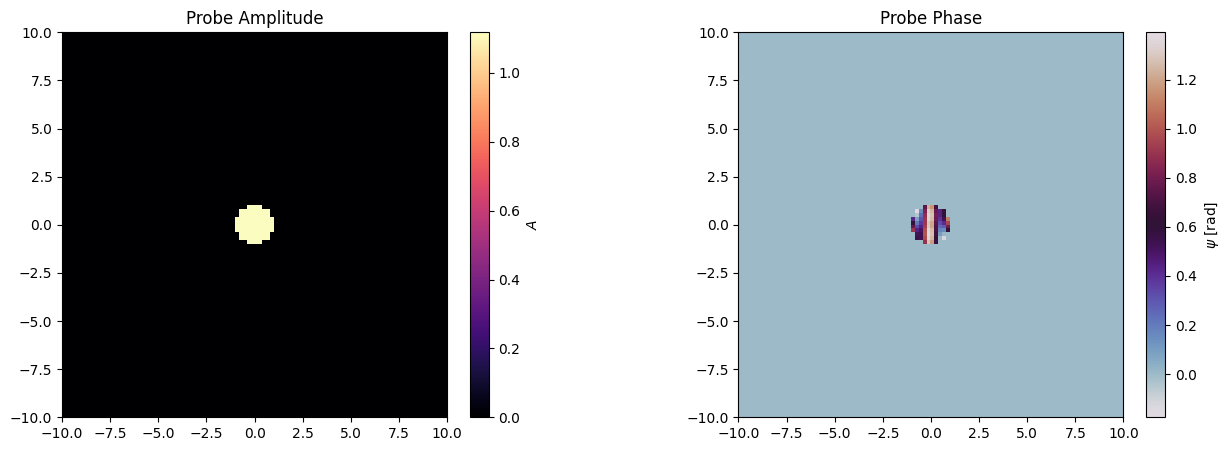

Probe fluence: tensor(100., dtype=torch.float64)


In [67]:
H, W = 100, 100
Lx = 10
Ly = 10

# Build theta, phi from meron-antimeron generator (returns torch tensors)
theta, phi, Mx, My, Mz = make_meron_antimeron_theta_phi(
    Nx=W,
    Ny=H,
    Lx=Lx,
    Ly=Ly,
    plot=False,
    save_path=None,
    export_path=None,
    return_torch=True,
    out_device=device,
    cm = RGB_scale,
)

# Physical XMLD/Jones constants
C = torch.tensor(50.0+ 50.0j, dtype=cdtype, device=device)
A1 = torch.tensor(5 + 30j, dtype=cdtype, device=device)
A2 = torch.tensor(4 + 20j, dtype=cdtype, device=device)

# Build Jones object from theta, phi
neel = NeelObject(C, A1, A2)
J = neel.build_jones(theta, phi)
obj = JonesObject(J)

# Grid for probe definition
x = torch.linspace(-Lx, Lx, H, device=device)
y = torch.linspace(-Ly, Ly, W, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')

# Define a probe with some phase structure on the wavefront.
fluence = torch.scalar_tensor(1e2, dtype=torch.float64, device=device)
R=torch.sqrt(X**2+Y**2) #This helps with defining the probe
R_probe = 1.0
Diffuser = 0.1*(torch.sin(1*R)+torch.cos((Y*5+X*1)-0.8*(X-0.2))+torch.cos((Y-X)-0.4*(X)))*(R<R_probe) #(torch.sqrt(3*X**2+1.5*Y**2)+torch.pi/3)#*(torch.exp(-0.1*R)) #np.mod(0.1*(torch.sin(150*R)+torch.cos((Y*10+X*30)**2-0.8*(X*75-0.2))+torch.cos((Y*10-X*33)**2-0.4*(X*50-0.2))),1)
P = torch.zeros_like(R)
P = torch.exp(2j*np.pi*Diffuser)*(R<R_probe)#*(torch.exp(-0.8*R))

# Calculate the Jones vectors of the probes for different Linear polarisation states
probes = []
pol_angles = [0, 30, 60, 90]
for angle in pol_angles:
    rad = np.deg2rad(angle)
    jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
    print(f'Jones vector for {angle} deg linear polarisation: {jones_vec}')
    probes.append(Probe(P, jones_vec, fluence=fluence, normalized=False))

print('Defined {} probes with different linear polarisation states.'.format(len(probes)))


plot_probe_maps(probes[0].amplitude, Lx, Ly)
print('Probe fluence:', probes[0].fluence)

# Define the scan trajectory, simulate the detector

In [68]:
xshiftvec = torch.linspace(-5, 5,15)
yshiftvec = torch.linspace(-5, 5,15)

# Shifting the text so that we can plot on the data
dx = (xshiftvec[1] - xshiftvec[0]) / 10
dy = (yshiftvec[1] - yshiftvec[0]) / 10

# Lab-coordinate scan grid used for plotting
xpos_lab, ypos_lab = torch.meshgrid(xshiftvec, yshiftvec, indexing="ij")
positions = torch.stack([ypos_lab.flatten(), xpos_lab.flatten()], dim=1)

# Convert lab coordinates into discrete pixel shifts for torch.roll(row, col)
pixel_size_y = (2 * Ly) / (H - 1)
pixel_size_x = (2 * Lx) / (W - 1)
positions_idx = torch.stack([
    torch.round(positions[:, 0] / pixel_size_y),
    torch.round(positions[:, 1] / pixel_size_x),
], dim=1).to(torch.int64)

scan = ScanTrajectory(positions_idx)

# Forward model
model = ForwardModel(obj, Propagator(), Detector(add_poisson_noise=True))
I_sim = model.simulate_all(probes, scan)
print('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)

C:\Users\godfrey\OneDrive - Nexus365\Documents\Google Drive (old computer 12_07_2022)\PhD\Year 3\Term 1\Ptycho\vector-ptycho\src\vector_ptycho\utils.py:483: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.positions = torch.tensor(positions, device=device)


Simulated data shape: torch.Size([4, 225, 100, 100])


C:\Users\godfrey\AppData\Local\Temp\ipykernel_45276\3983109005.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  (np.log10(I_sim[probe_number, scan_idx].cpu()+1e-8)),


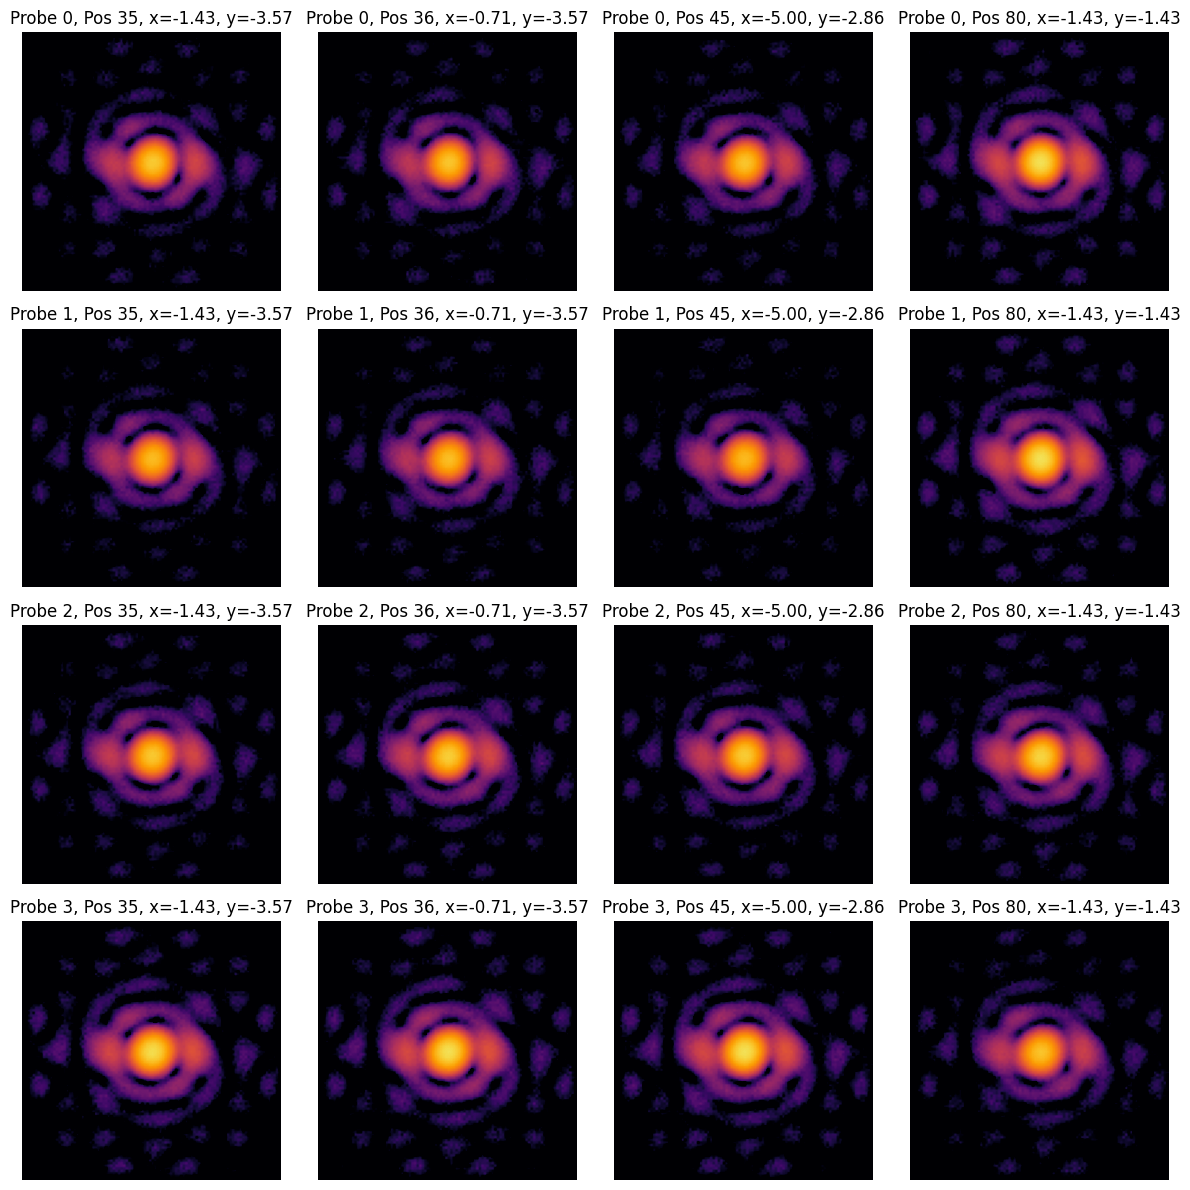

In [69]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

#scan_indices = [35, 36, 45, 43]
scan_indices = [35, 36, 45, 80]
probe_numbers = [0, 1, 2, 3]

for i, probe_number in enumerate(probe_numbers):      # rows
    for j, scan_idx in enumerate(scan_indices):       # columns
        
        axes[i, j].imshow(
            (np.log10(I_sim[probe_number, scan_idx].cpu()+1e-8)),
            cmap='inferno',
            vmin=1,
            vmax=4
        )
        
        '''
        axes[i, j].imshow(
            np.log10(I_sim[probe_number, scan_idx].cpu()+1e-8),
            cmap='inferno',
        )
        '''
        axes[i, j].set_title(f'Probe {probe_number}, Pos {scan_idx}, x={positions[scan_idx, 0].item():.2f}, y={positions[scan_idx, 1].item():.2f}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Normalise I_sim for the autograd - divide by the mean to keep values around 1, which helps with the gradients - now l has a magnitude of 1, probe and detector have values around 1, so the gradients are nicely balanced and we don't have to worry about vanishing or exploding gradients as much.
I_sim /= I_sim.mean()

In [70]:
def normalise_neel(l):
    # Normalize to ensure L is always a unit vector
    mag = torch.sqrt(torch.sum(l**2, dim=0) + 1e-8)
    Lx = l[0] / mag
    Ly = l[1] / mag
    Lz = l[2] / mag
    return Lx, Ly, Lz

def optimize_object_and_probe_with_scheduler(scan, pol_angles, I_meas, H, W, initial_l, initial_probe_amplitude,num_iterations=100, device=None, 
                                             loss_prefactors={'sqrt_amp_pf': 1.0, 'gradient_pf': 1e-4, 'anisotropy_pf': 1e-4, 'probe_localisation_pf': 1e-3},
                                             optimizer_params={'l_lr': 1e-3, 'CA_lr': 1e-5, 'probe_lr': 60e-1},
                                             plot_filename=None, object_randomisation=False, probe_randomisation=False):
    """
    Reconstruct probes (different for each polarisation) l C, A1, A2 from measured diffraction patterns.
    This is different to previous versions because it directly updates lx, ly, lz to avoid differentiation problems associated with angular coordinates.
    .
    Parameters
    ----------
    scan : ScanTrajectory
        Scan positions.
    pol_angles : list of float
        List of polarisation angles in degrees for each probe.
    I_meas : torch.Tensor
        Measured diffraction intensities, shape (N_probes, N_scan, Hdet, Wdet)
    H, W : int
        Object map size.
    initial_l : torch.Tensor
        Initial guess for the neel vector in Cartesian coordinates, shape (3, H, W).
    initial_probe_amplitude : torch.Tensor
        Initial guess for the probe amplitude, shape (H, W).
    num_iterations : int
        Number of optimization steps.
    device : torch.device or str
        Device to use.
    loss_prefactors : dict
        Prefactors for different loss components - how much to weight anisotropy and gradient losses relative to the amplitude loss.
    optimizer_params : dict
        Learning rates for different parameter groups in the optimizer.
    plot_filename : str or None
        If not None, save intermediate plots to this filename during optimization.
    object_randomisation : bool
        Whether to apply randomisation to the object parameters during optimization to help escape local minima.
    probe_randomisation : bool
        Whether to apply randomisation to the probe parameters during optimization to help escape local minima.
     Returns
    -------
    dict
        Reconstructed parameters and loss history.
    """
    if device is None:
        device = I_meas.device

    # This is for the live plot updates
    plot_update = create_live_plotter(Lx, Ly, phi_cmap=RGB_scale, theta_cmap='magma')

    eps = 1e-12
    cdtype = torch.complex64

    # Learnable parameters

    l = torch.nn.Parameter(initial_l) # Defining the neel vector in terms of it's lx, ly, lz components, which are then normalised to get theta and phi. This is easier to optimise than directly optimising theta and phi, which have singularities at the poles.
    probe_amplitude = initial_probe_amplitude

    # Initialise the probe array (same for all pol states at the moment)
    probes = []
    for angle in pol_angles:
        rad = np.deg2rad(angle)
        jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
        probes.append(Probe(probe_amplitude, jones_vec, fluence=fluence, normalized=False))
    probe_amplitude = torch.nn.Parameter(probes[0].amplitude) #It has now been normalised to the correct fluence.
    probe_amplitude_start = probes[0].amplitude
    fluence_calc = torch.sum(torch.abs(probe_amplitude_start)**2)
    print(f"Calculated initial fluence from probe amplitude: {fluence_calc.item():.6e}, target fluence: {fluence.item():.6e}")

    optimizer = torch.optim.Adam([
        {"params": [l], "lr": optimizer_params['l_lr']},
        {"params": [C, A1, A2], "lr": optimizer_params['CA_lr']},
        {"params": [probe_amplitude], "lr": optimizer_params['probe_lr']}
        ])
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,       # reduce LR by 2x
        patience=5,      # wait 5 iterations without improvement
        threshold=1e-3,   # minimum change to count as improvement
        min_lr=1e-6,      # don't go too small
    )
    loss_history = []

    for iteration in range(num_iterations):
        optimizer.zero_grad(set_to_none=True)

        l_mag = torch.sqrt(torch.sum(l**2, dim=0) + 1e-8) 
        
        # Create normalized Cartesian components
        lx_norm = l[0] / l_mag
        ly_norm = l[1] / l_mag
        lz_norm = l[2] / l_mag

        # Build Jones object from current parameters
        neel = NeelObject(C, A1, A2)
        J = neel.build_jones_from_cartesian(lx= lx_norm, ly=ly_norm, lz=lz_norm)
        obj = JonesObject(J)

        # Remake the probe array
        probes = []
        for angle in pol_angles:
            rad = np.deg2rad(angle)
            jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
            probes.append(Probe(probe_amplitude, jones_vec, fluence=fluence, normalized=True))

        # Forward model
        model = ForwardModel(obj, Propagator(), Detector())
        I_pred = model.simulate_all(probes, scan)
        eps = 1e-8

        fluence_calc = torch.sum(torch.abs(probe_amplitude)**2)
        print(f"Calculated fluence from probe amplitude: {fluence_calc.item():.6e}, target fluence: {fluence.item():.6e}")
        '''
        if loss_prefactors['gradient_pf'] > 0 or loss_prefactors['anisotropy_pf'] > 0:
            #Only perform this computation if the prefactors are > 0, as it is quite expensive.

            # 2. Compute spatial gradients using finite differences
            # Differences along the X-axis (width)
            dx_lx = torch.diff(lx_norm, dim=-1)
            dx_ly = torch.diff(ly_norm, dim=-1)
            dx_lz = torch.diff(lz_norm, dim=-1)

            # Differences along the Y-axis (height)
            dy_lx = torch.diff(lx_norm, dim=-2)
            dy_ly = torch.diff(ly_norm, dim=-2)
            dy_lz = torch.diff(lz_norm, dim=-2)

            grad_mag_x = torch.sqrt(dx_lx**2 + dx_ly**2 + dx_lz**2 + 1e-8) # 1e-8 prevents NaN in sqrt at 0
            grad_mag_y = torch.sqrt(dy_lx**2 + dy_ly**2 + dy_lz**2 + 1e-8)

            loss_x = torch.sum(grad_mag_x**2)
            loss_y = torch.sum(grad_mag_y**2)

            gradient_loss = loss_x + loss_y
            anisotropy_loss = torch.sum(l[2]**2) # Positive prefactor will favour IP alignment.
        else:
            gradient_loss = 0.0
            anisotropy_loss = 0.0
        '''
        '''
        # Amplitude-based ptychographic loss
        if loss_prefactors['probe_localisation_pf'] > 0:
            probe_localisation_loss = loss_prefactors['probe_localisation_pf'] * torch.mean(torch.abs(probe_amplitude)**2*R**2) #This stops the probe from drifting by penalising amplitude at large R
        else:
            probe_localisation_loss = 0.0
        '''
        # Define the loss function
        loss = loss_prefactors['sqrt_amp_pf'] * torch.mean((torch.sqrt(I_pred + eps) - torch.sqrt(I_meas + eps))**2) #+ loss_prefactors['gradient_pf'] * gradient_loss + loss_prefactors['anisotropy_pf'] * anisotropy_loss + probe_localisation_loss

        loss.backward()
        optimizer.step()

        # Step the scheduler with the current loss
        scheduler.step(loss)

        if iteration % 20 == 0:
            print([group['lr'] for group in optimizer.param_groups])
        
        if iteration % 8 == 0 and iteration < 30:
            with torch.no_grad():
                if probe_randomisation:
                    probe_amplitude.data += (torch.rand((H, W), device=device) * torch.max(torch.abs(probe_amplitude))*0.25)
                if object_randomisation:
                    l[0].data += (torch.rand((H, W), device=device) * 0.15)
                    l[1].data += (torch.rand((H, W), device=device) * 0.15)
                    l[2].data += (torch.rand((H, W), device=device) * 0.15)

        loss_history.append(loss.item())

        if iteration % 1 == 0:
            theta = torch.acos(lz_norm)
            phi = torch.atan2(ly_norm, lx_norm)
            l_mag = torch.sqrt(torch.sum(l**2, dim=0) + 1e-8)
            print(f"Iter {iteration:4d} | Loss = {loss.item():.6e}")
            plot_update(probe_amplitude, theta, phi, loss, save_filename=plot_filename)

    return {
        "l": l.detach(),
        "probe_amplitude": probe_amplitude.detach(),
        "C": C.detach(),
        "A1": A1.detach(),
        "A2": A2.detach(),
        "loss_history": loss_history,
        "optimizer_params": optimizer_params,
        "loss_prefactors": loss_prefactors,   
    }

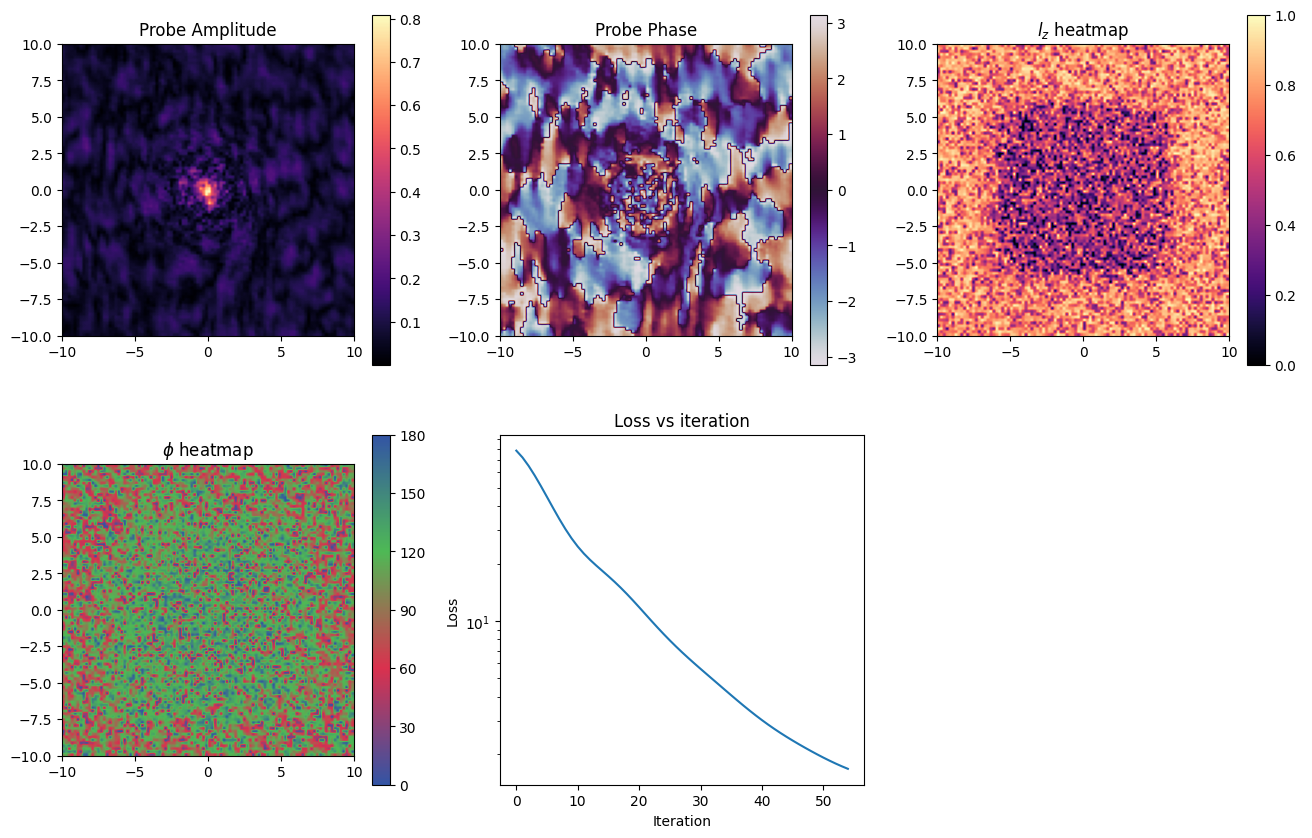

Calculated initial fluence from probe amplitude: 1.000000e+02, target fluence: 1.000000e+02
Calculated fluence from probe amplitude: 1.000000e+02, target fluence: 1.000000e+02
[0.01, 1e-05, 0.01]
Iter    0 | Loss = 7.807149e+01
Calculated fluence from probe amplitude: 9.783157e+01, target fluence: 1.000000e+02
Iter    1 | Loss = 7.193254e+01
Calculated fluence from probe amplitude: 9.708237e+01, target fluence: 1.000000e+02
Iter    2 | Loss = 6.496822e+01
Calculated fluence from probe amplitude: 9.811465e+01, target fluence: 1.000000e+02
Iter    3 | Loss = 5.781984e+01
Calculated fluence from probe amplitude: 1.010168e+02, target fluence: 1.000000e+02
Iter    4 | Loss = 5.093586e+01
Calculated fluence from probe amplitude: 1.056609e+02, target fluence: 1.000000e+02
Iter    5 | Loss = 4.461364e+01
Calculated fluence from probe amplitude: 1.117774e+02, target fluence: 1.000000e+02
Iter    6 | Loss = 3.902473e+01
Calculated fluence from probe amplitude: 1.189901e+02, target fluence: 1.000

KeyboardInterrupt: 

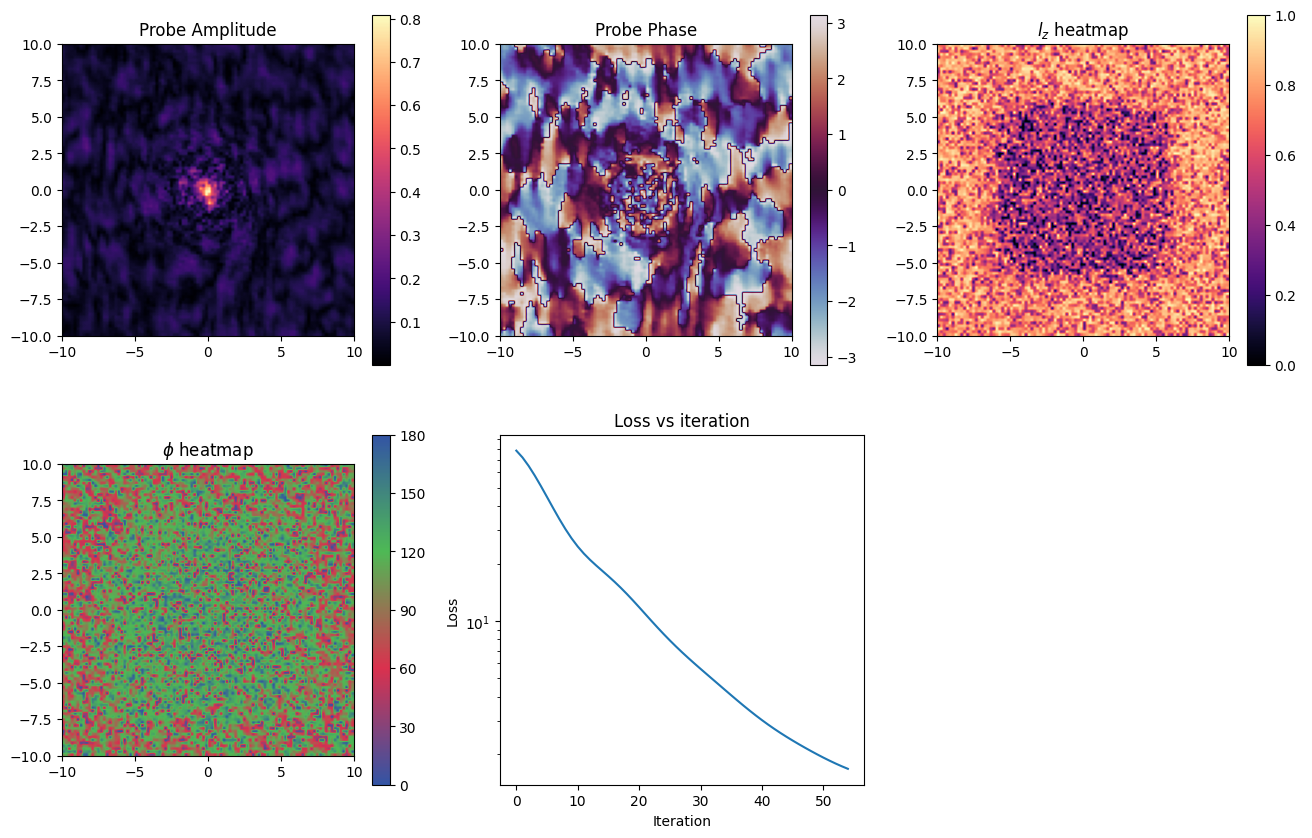

In [73]:
initial_l = torch.randn(3, H, W, device=device)
P_test = torch.zeros_like(R)
Diffuser = torch.rand((H, W), device=device)
P_test = torch.exp(2j*np.pi*Diffuser)*(torch.exp(-0.8*R))
initial_probe_amplitude = P_test

optimizer_params={'l_lr': 1e-2, 'CA_lr': 1e-5, 'probe_lr': 1e-2}
loss_prefactors={'sqrt_amp_pf': 1.0, 'gradient_pf': 1e-4, 'anisotropy_pf': 1e-4, 'probe_localisation_pf':0.0} # Different parts of the Loss have different weights

'''Randomisation can help a minimum be found - this section tells what gets randomised, by how much and when it stops taking effect'''
object_randomisation = False # Randomise the object at the start of the optimization to help escape local minima
probe_randomisation = False # Randomise the probe at the start of the optimization to help escape local minima
randomisation_dict = {'object_randomisation': object_randomisation, 'probe_randomisation': probe_randomisation,
                      'object_rand_pf': 0.15, 'probe_rand_pf': 0.1, 'iter_spacing': 5, 'final_iteration': 50}

result = optimize_object_and_probe_with_scheduler(scan, pol_angles, I_sim, H, W,
                                   initial_probe_amplitude=initial_probe_amplitude,
                                   initial_l=initial_l,
                                   num_iterations=800, device=device, loss_prefactors=loss_prefactors, object_randomisation=object_randomisation, probe_randomisation=probe_randomisation, optimizer_params=optimizer_params)



## Loop through a few different hyperparameters

In [ ]:
import itertools
import pickle
import os

# Initial probe and object
initial_theta = torch.nn.Parameter(torch.rand((H, W), device=device) * 0.01 + torch.pi/2)
initial_phi   = torch.nn.Parameter(torch.rand((H, W), device=device) * 0.1 + torch.pi/2)

P_test = torch.zeros_like(R)
Diffuser = torch.rand((H, W), device=device)
P_test = torch.exp(2j*np.pi*Diffuser)*(torch.exp(-0.8*R))
initial_probe_amplitude = P_test


# --- hyperparameter ranges ---
gradient_pf_list = [1.0, 1e-1, 1e-1]
anisotropy_pf_list = [1.0, 1e-1, 1e-1]

base_loss_prefactors = {
    'sqrt_amp_pf': 1.0,
}

optimizer_params = {
    'theta_lr': 5e-1,
    'phi_lr': 5e-1,
    'CA_lr': 1e-5,
    'probe_lr': 60e-1
}

output_dir = "hyperparam_runs"
os.makedirs(output_dir, exist_ok=True)

# --- loop ---
for gradient_pf, anisotropy_pf in itertools.product(gradient_pf_list, anisotropy_pf_list):
    
    loss_prefactors = {
        **base_loss_prefactors,
        'gradient_pf': gradient_pf,
        'anisotropy_pf': anisotropy_pf
    }
    
    run_name = f"grad_{gradient_pf:.0e}_anis_{anisotropy_pf:.0e}"
    
    plot_filename = os.path.join(output_dir, f"plot_{run_name}.png")
    pickle_filename = os.path.join(output_dir, f"result_{run_name}.pkl")
    
    print(f"Running: {run_name}")
    
    result = optimize_object_and_probe_with_scheduler(
        scan, pol_angles, I_sim, H, W,
        initial_theta=initial_theta,
        initial_phi=initial_phi,
        initial_probe_amplitude=initial_probe_amplitude,
        num_iterations=80,
        device=device,
        loss_prefactors=loss_prefactors,
        plot_filename=plot_filename
    )
    
    # optional: include params explicitly in saved object
    result_to_save = {
        "run_name": run_name,
        "gradient_pf": gradient_pf,
        "anisotropy_pf": anisotropy_pf,
        "result": result
    }
    
    # save immediately
    with open(pickle_filename, "wb") as f:
        pickle.dump(result_to_save, f)

    print(f"Saved: {pickle_filename}")

In [ ]:
import os
import pickle
import glob
import matplotlib.pyplot as plt

results_dir = "hyperparam_runs"

# find all pickle files
pickle_files = sorted(glob.glob(os.path.join(results_dir, "result_*.pkl")))

plt.figure()

for pf in pickle_files:
    with open(pf, "rb") as f:
        data = pickle.load(f)
    
    run_name = data["run_name"]
    loss_history = data["result"]["loss_history"]
    
    plt.plot(loss_history, label=run_name)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Loss history for different hyperparameters")

# optional: legend can get crowded
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
plot_probe_maps(result["probe_amplitude"].detach().cpu().numpy(), Lx, Ly)
plot_theta_phi_maps(
    result["theta"].detach().cpu().numpy(),
    result["phi"].detach().cpu().numpy(),
    Lx,
    Ly,
    theta_cmap='magma',
    phi_cmap=RGB_scale,
    label_axes=True,
)

In [ ]:
plt.plot(result["loss_history"])
plt.ylabel('Loss')
plt.xlabel('Iteration')
plt.yscale('log')
plt.show()